Part 1 — PCA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
TICKERS = [
    "SPY",
    "QQQ",
    "IWM",
    "XLF",
    "XLK",
    "XLE",
]

raw = yf.download(
    TICKERS,
    start="2016-01-01",
    end="2026-01-01",
    auto_adjust=False,
    progress=False
)

In [3]:
prices = raw["Adj Close"].copy()

In [4]:
returns = prices.pct_change().dropna()

In [5]:
returns.corr()

Ticker,IWM,QQQ,SPY,XLE,XLF,XLK
Ticker,,,,,,
IWM,1.000000,0.765787,0.866456,0.649495,0.822127,0.755003
QQQ,0.765787,1.000000,0.933254,0.432161,0.654558,0.974870
SPY,0.866456,0.933254,1.000000,0.616128,0.841341,0.930136
XLE,0.649495,0.432161,0.616128,1.000000,0.685447,0.450573
XLF,0.822127,0.654558,0.841341,0.685447,1.000000,0.662026
XLK,0.755003,0.974870,0.930136,0.450573,0.662026,1.000000


In [6]:
train_returns = returns.loc[:"2022-12-31"]
test_returns = returns.loc["2023-01-01":]

In [7]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(
    train_returns
)

test_scaled = scaler.transform(
    test_returns
)

In [8]:
pca = PCA()

pca.fit(train_scaled)

PCA()

In [9]:
explained = pca.explained_variance_ratio_

explained

array([0.80495312, 0.12250525, 0.04140249, 0.02427254, 0.00373265,
       0.00313395])

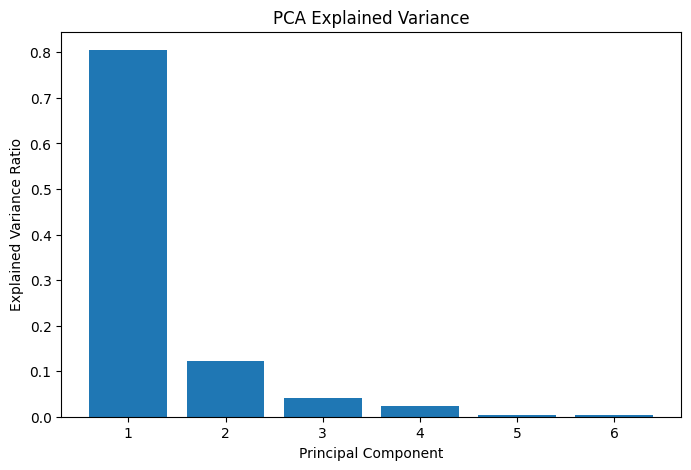

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, len(explained) + 1),
    explained
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")

plt.show()

In [11]:
np.cumsum(explained)

array([0.80495312, 0.92745837, 0.96886085, 0.99313339, 0.99686605,
       1.        ])

In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=TICKERS,
    columns=[
        f"PC{i+1}"
        for i in range(len(TICKERS))
    ]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6
SPY,0.423287,0.116497,0.278488,0.850136,-0.076541,-0.033340
QQQ,0.413688,-0.448332,-0.244747,-0.020746,0.164238,0.735224
IWM,0.447899,-0.120117,0.028843,-0.169794,0.723169,-0.482000
XLF,0.331261,0.717344,-0.605405,-0.066282,-0.039765,0.056520
XLK,0.404189,0.303079,0.664229,-0.469924,-0.197309,0.209320
XLE,0.419493,-0.405659,-0.232370,-0.150955,-0.635360,-0.423085


Part 2 — Create Market Regime

In [13]:
processed_data = pd.read_csv(
    "../data/processed/spy_features.csv",
    index_col=0,
    parse_dates=True
)

In [14]:
train = processed_data.loc[:"2022-12-31"].copy()
test = processed_data.loc["2023-01-01":].copy()

low_threshold = (
    train["vol_20d"].quantile(0.33)
)

high_threshold = (
    train["vol_20d"].quantile(0.67)
)

def classify_regime(vol):
    if vol < low_threshold:
        return "Low Vol"

    elif vol < high_threshold:
        return "Normal Vol"

    else:
        return "High Vol"

processed_data["regime"] = (
    processed_data["vol_20d"]
    .apply(classify_regime)
)


Part 3 — Is signal different in different regimes?

In [15]:
regime_stats = (
    processed_data[
        processed_data["zscore_20d"] < -2
    ]
    .groupby("regime")["next_return"]
    .agg([
        "mean",
        "median",
        "std",
        "count"
    ])
)

regime_stats

,mean,median,std,count
regime,,,,
High Vol,0.008383,0.002561,0.030986,38
Low Vol,0.000484,0.001130,0.011652,14
Normal Vol,0.002308,0.004205,0.012123,57


Part 4 — Create simplest Z-score strategy

In [16]:
position_z = pd.Series(
    0.0,
    index=processed_data.index
)

In [ ]:
position_z[
    processed_data["zscore_20d"] < -2
] = 1

position_z[
    processed_data["zscore_20d"] > 2
] = -1

Part 5 — Time alignment

In [18]:
strategy_return_z = (
    position_z
    * processed_data["next_return"]
)

Part 6 — Check test period

In [19]:
test_mask = (
    processed_data.index >= "2023-01-01"
)

z_test_return = (
    strategy_return_z[test_mask]
    .dropna()
)

Part 7 — transaction cost

In [20]:
turnover_z = (
    position_z.diff().abs()
)

COST_PER_UNIT_TURNOVER = 0.0005

cost_z = (
    turnover_z
    * COST_PER_UNIT_TURNOVER
)

net_return_z = (
    strategy_return_z
    - cost_z
)

Part 8 — Sharpe Ratio

In [21]:
def annualized_sharpe(r):
    return (
        r.mean()
        / r.std()
        * np.sqrt(252)
    )

Part 9 — Annualized Return

In [22]:
def annualized_return(r):
    cumulative = (
        1 + r
    ).prod()

    n_years = (
        len(r) / 252
    )

    return (
        cumulative ** (1 / n_years)
        - 1
    )

Part 10 — Annualized Volatility

In [23]:
def annualized_volatility(r):
    return (
        r.std() * np.sqrt(252)
    )

Part 11 — Maximum Drawdown

In [24]:
def equity_curve(r):
    return (
        1 + r
    ).cumprod()

In [25]:
def max_drawdown(r):

    equity = equity_curve(r)

    peak = equity.cummax()

    drawdown = (
        equity / peak - 1
    )

    return drawdown.min()

Part 12 — Turnover

In [26]:
def average_turnover(position):
    return (
        position.diff().abs().mean()
    )

def annualized_turnover(position):
    return (
        position.diff().abs().mean()
        * 252
    )

Part 13 — Unify performance function

In [28]:
def strategy_metrics(
    returns,
    position
):

    returns = returns.dropna()

    metrics = {
        "Annualized Return":
            annualized_return(returns),

        "Annualized Vol":
            annualized_volatility(returns),

        "Sharpe":
            annualized_sharpe(returns),

        "Max Drawdown":
            max_drawdown(returns),

        "Annualized Turnover":
            annualized_turnover(
                position.loc[returns.index]
            )
    }

    return metrics

Part 14 — Judge Z-score strategy

In [29]:
test_position_z = (
    position_z.loc["2023-01-01":]
)

test_return_z = (
    net_return_z.loc["2023-01-01":]
)

z_metrics = strategy_metrics(
    test_return_z,
    test_position_z
)

z_metrics

{'Annualized Return': np.float64(0.003129125730457316),
 'Annualized Vol': np.float64(0.07877850297436058),
 'Sharpe': np.float64(0.07780387856435302),
 'Max Drawdown': np.float64(-0.10566966897880137),
 'Annualized Turnover': np.float64(29.567999999999998)}

Part 15 — Load saved model predictions

In [38]:
reg_preds = pd.read_csv(
    "../data/processed/regression_predictions.csv",
    index_col=0,
    parse_dates=True
)

reg_preds.head()

,actual_return,linear_pred,ridge_pred,lasso_pred
Date,,,,
2023-01-03,0.007720,0.001839,0.001841,0.002093
2023-01-04,-0.011413,-0.002764,-0.002759,-0.002202
2023-01-05,0.022932,0.003648,0.003643,0.003048
2023-01-06,-0.000567,-0.004199,-0.004195,-0.003795
2023-01-09,0.007013,0.001859,0.001860,0.001744


In [39]:
clf_preds = pd.read_csv(
    "../data/processed/classification_predictions.csv",
    index_col=0,
    parse_dates=True
)

clf_preds.head()

,actual_up,logit_prob_up,rf_prob_up
Date,,,
2023-01-03,1,0.555641,0.556701
2023-01-04,0,0.535563,0.548075
2023-01-05,1,0.558709,0.554219
2023-01-06,0,0.525219,0.504592
2023-01-09,1,0.551944,0.550855


In [40]:
test_return = (
    reg_preds["actual_return"]
    .copy()
)

In [41]:
print(
    "Test period:",
    test_return.index.min(),
    "to",
    test_return.index.max()
)

print(
    "Number of test observations:",
    len(test_return)
)

Test period: 2023-01-03 00:00:00 to 2025-12-30 00:00:00
Number of test observations: 751


In [42]:
position_z_test = (
    position_z
    .reindex(test_return.index)
    .fillna(0.0)
)

In [43]:
print(
    test_return.index.equals(
        position_z_test.index
    )
)

True


Part 16 — Convert predictions to trading positions

In [44]:
#16.1 Buy & Hold

position_buy_hold = pd.Series(
    1.0,
    index=test_return.index
)

#16.2 Z-score strategy

position_z_test

Date
2023-01-03    0.0
2023-01-04    0.0
2023-01-05    0.0
2023-01-06    0.0
2023-01-09    0.0
             ... 
2025-12-23    0.0
2025-12-24    0.0
2025-12-26    0.0
2025-12-29    0.0
2025-12-30    0.0
Length: 751, dtype: float64

In [45]:
# 16.3 Linear Regression

position_linear = np.sign(
    reg_preds["linear_pred"]
)

#16.4 Ridge

position_ridge = np.sign(
    reg_preds["ridge_pred"]
)

#16.5 Lasso

position_lasso = np.sign(
    reg_preds["lasso_pred"]
)

In [46]:
#16.6 Logistic Regression

logit_prob = (
    clf_preds["logit_prob_up"]
    .reindex(test_return.index)
)

position_logit = pd.Series(
    0.0,
    index=test_return.index
)

position_logit[
    logit_prob > 0.55
] = 1.0

position_logit[
    logit_prob < 0.45
] = -1.0

In [47]:
#16.7 Random Forest

rf_prob = (
    clf_preds["rf_prob_up"]
    .reindex(test_return.index)
)

position_rf = pd.Series(
    0.0,
    index=test_return.index
)

position_rf[
    rf_prob > 0.55
] = 1.0

position_rf[
    rf_prob < 0.45
] = -1.0

In [48]:
positions = {
    "Buy & Hold": position_buy_hold,
    "Z-score": position_z_test,
    "Linear": position_linear,
    "Ridge": position_ridge,
    "Lasso": position_lasso,
    "Logistic": position_logit,
    "Random Forest": position_rf,
}

for name, position in positions.items():
    print(
        name,
        position.value_counts().to_dict()
    )

Buy & Hold {1.0: 751}
Z-score {0.0: 676, -1.0: 43, 1.0: 32}
Linear {1.0: 492, -1.0: 259}
Ridge {1.0: 492, -1.0: 259}
Lasso {1.0: 486, -1.0: 265}
Logistic {0.0: 450, 1.0: 301}
Random Forest {1.0: 561, 0.0: 185, -1.0: 5}


Part 17 — Gross returns, turnover and transaction costs

In [49]:
gross_returns = {}

for name, position in positions.items():

    gross_returns[name] = (
        position
        * test_return
    )

In [52]:
#Turnover


def calculate_turnover(position):

    return (
        position
        .diff()
        .abs()
        .fillna(
            position.abs()
        )
    )

COST_PER_UNIT_TURNOVER = 0.0005


def apply_transaction_cost(
    gross_return,
    position,
    cost_per_unit=0.0005
):

    turnover = calculate_turnover(
        position
    )

    transaction_cost = (
        turnover
        * cost_per_unit
    )

    net_return = (
        gross_return
        - transaction_cost
    )

    return (
        net_return,
        turnover,
        transaction_cost
    )

In [53]:
net_returns = {}
turnovers = {}
transaction_costs = {}

for name in positions:

    (
        net_ret,
        turnover,
        cost
    ) = apply_transaction_cost(
        gross_returns[name],
        positions[name],
        COST_PER_UNIT_TURNOVER
    )

    net_returns[name] = net_ret
    turnovers[name] = turnover
    transaction_costs[name] = cost

Part 18 — Performance metrics

In [54]:
#18.1 Annualized return

def annualized_return(r):

    r = r.dropna()

    total_growth = (
        1 + r
    ).prod()

    n_years = (
        len(r) / 252
    )

    return (
        total_growth ** (1 / n_years)
        - 1
    )

# 18.2 Annualized volatility

def annualized_volatility(r):

    r = r.dropna()

    return (
        r.std()
        * np.sqrt(252)
    )

# 18.3 Sharpe ratio

def sharpe_ratio(r):

    r = r.dropna()

    if r.std() == 0:
        return np.nan

    return (
        r.mean()
        / r.std()
        * np.sqrt(252)
    )

#18.4 Max drawdown

def max_drawdown(r):

    r = r.dropna()

    equity = (
        1 + r
    ).cumprod()

    running_peak = (
        equity.cummax()
    )

    drawdown = (
        equity
        / running_peak
        - 1
    )

    return drawdown.min()

# 18.5 Annualized turnover

def annualized_turnover(turnover):

    return (
        turnover.mean()
        * 252
    )

#18.6 Trading frequency

def active_fraction(position):

    return (
        position != 0
    ).mean()

Part 19 — Final comparison table

In [55]:
results = {}

for name in positions:

    r = net_returns[name]

    results[name] = {

        "Annualized Return":
            annualized_return(r),

        "Annualized Vol":
            annualized_volatility(r),

        "Sharpe":
            sharpe_ratio(r),

        "Max Drawdown":
            max_drawdown(r),

        "Annualized Turnover":
            annualized_turnover(
                turnovers[name]
            ),

        "Active Fraction":
            active_fraction(
                positions[name]
            )
    }


results_df = pd.DataFrame(
    results
).T
results_df


,Annualized Return,Annualized Vol,Sharpe,Max Drawdown,Annualized Turnover,Active Fraction
Buy & Hold,0.231924,0.153500,1.435592,-0.187552,0.335553,1.000000
Z-score,0.003129,0.078779,0.077804,-0.105670,29.528628,0.099867
Linear,-0.114008,0.154221,-0.708258,-0.381984,258.039947,1.000000
Ridge,-0.114008,0.154221,-0.708258,-0.381984,258.039947,1.000000
Lasso,-0.103148,0.154168,-0.629573,-0.390905,256.697736,1.000000
Logistic,0.074638,0.114883,0.683173,-0.136677,109.054594,0.400799
Random Forest,0.221932,0.128691,1.621542,-0.108658,72.143808,0.753662


In [56]:
display_results = (
    results_df.copy()
)

for col in [
    "Annualized Return",
    "Annualized Vol",
    "Max Drawdown",
    "Active Fraction"
]:
    display_results[col] = (
        display_results[col]
        * 100
    )

display_results.round(3)

,Annualized Return,Annualized Vol,Sharpe,Max Drawdown,Annualized Turnover,Active Fraction
Buy & Hold,23.192,15.350,1.436,-18.755,0.336,100.000
Z-score,0.313,7.878,0.078,-10.567,29.529,9.987
Linear,-11.401,15.422,-0.708,-38.198,258.040,100.000
Ridge,-11.401,15.422,-0.708,-38.198,258.040,100.000
Lasso,-10.315,15.417,-0.630,-39.090,256.698,100.000
Logistic,7.464,11.488,0.683,-13.668,109.055,40.080
Random Forest,22.193,12.869,1.622,-10.866,72.144,75.366


Part 20 — Equity curves

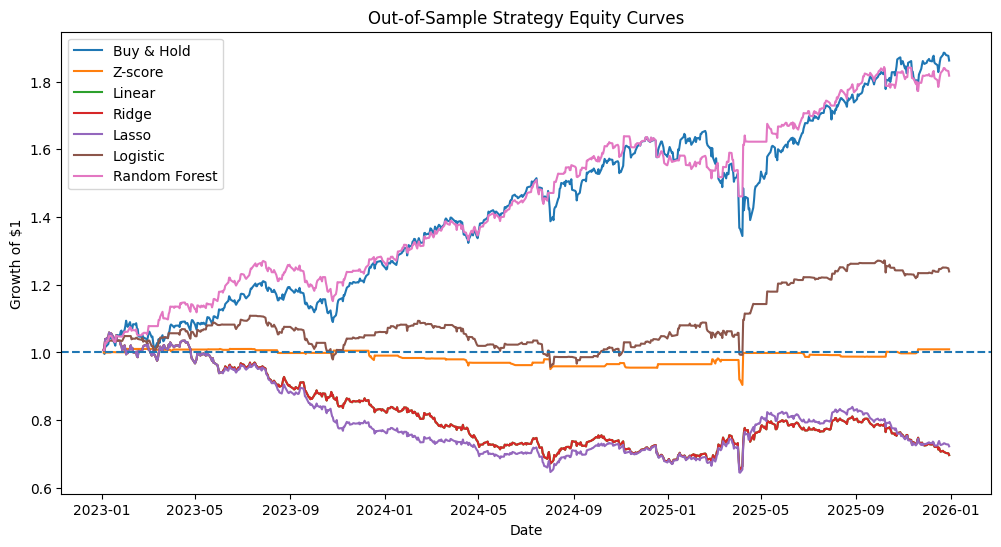

In [57]:
equity_curves = pd.DataFrame(
    index=test_return.index
)

for name, r in net_returns.items():

    equity_curves[name] = (
        1 + r.fillna(0)
    ).cumprod()


plt.figure(
    figsize=(12, 6)
)

for name in equity_curves.columns:

    plt.plot(
        equity_curves.index,
        equity_curves[name],
        label=name
    )

plt.axhline(
    1.0,
    linestyle="--"
)

plt.title(
    "Out-of-Sample Strategy Equity Curves"
)

plt.ylabel(
    "Growth of $1"
)

plt.xlabel(
    "Date"
)

plt.legend()

plt.show()

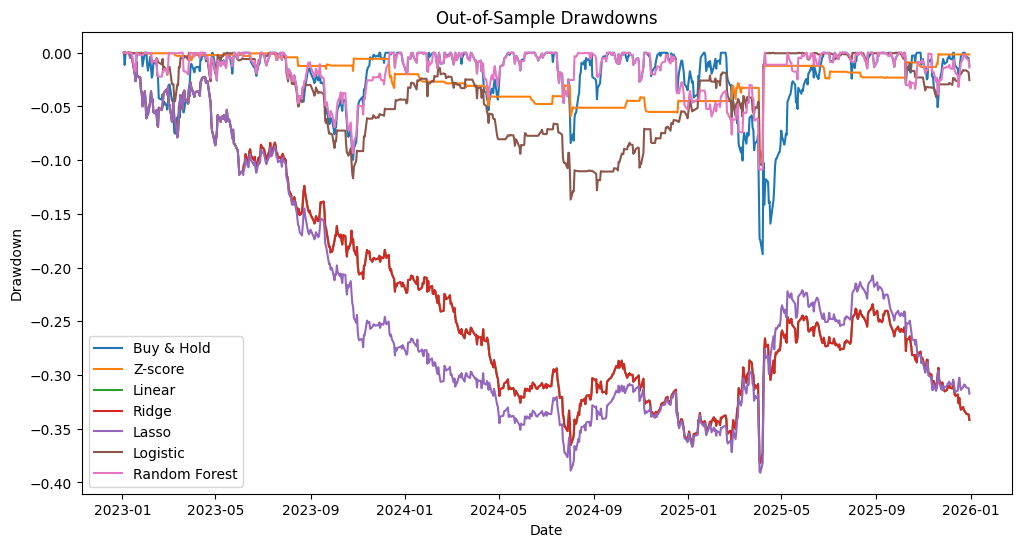

In [58]:
plt.figure(
    figsize=(12, 6)
)

for name in equity_curves.columns:

    equity = equity_curves[name]

    peak = equity.cummax()

    dd = (
        equity / peak - 1
    )

    plt.plot(
        dd.index,
        dd,
        label=name
    )

plt.title(
    "Out-of-Sample Drawdowns"
)

plt.ylabel(
    "Drawdown"
)

plt.xlabel(
    "Date"
)

plt.legend()

plt.show()